In [1]:
from thinkbayes import Suite
import thinkbayes

class Euro(Suite):

    def Likelihood(self, data, hypo):
        x = hypo
        if data == 'H':
            return x/100.0
        else:
            return 1 - x/100.0
        
posts = range(1,101)
suite = Euro(posts)
dataset = 'H' * 140 + 'T' * 110

for data in dataset:
    suite.Update(data)

suite.Items()

post = [v for k, v in suite.Items()]

print(suite.Mean())



55.952380952380956


In [2]:
best_hypo, best_prob = max(suite.Items(),
                           key=lambda x: x[1])

print(best_hypo, best_prob)

56 0.12745318058391095


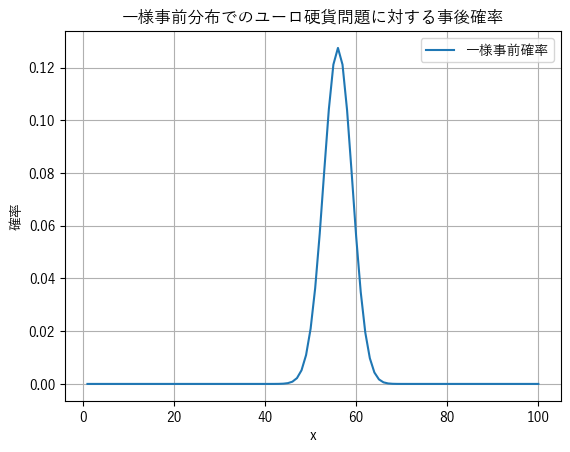

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'YuGothic'

hypos = range(1,101)

plt.plot(hypos, post, label="一様事前確率")

plt.xlabel('x')
plt.ylabel('確率')

plt.title('一様事前分布でのユーロ硬貨問題に対する事後確率')
plt.legend()
plt.grid(True)
    

In [4]:
Median = thinkbayes.Percentile(suite, 50)
print(Median)

56


In [5]:
ci = thinkbayes.CredibleInterval(suite, 90)
print(ci)

(51, 61)


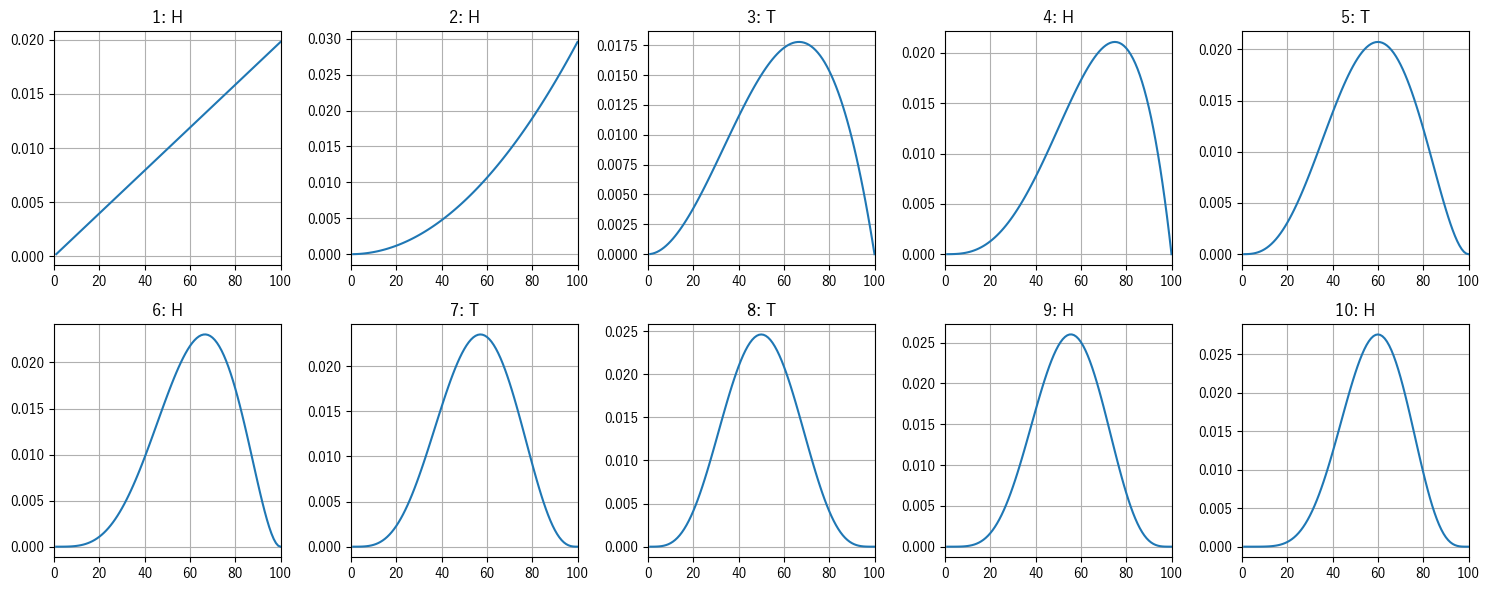

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from thinkbayes import Suite


# ------------------------------------
# コイン問題
# ------------------------------------
class Euro(Suite):

    def Likelihood(self, data, hypo):

        x = hypo / 100.0

        if data == 'H':
            return x
        else:
            return 1 - x


# ------------------------------------
# 仮説（1%～100%）
# ------------------------------------
hypos = range(1, 101)
suite = Euro(hypos)

# ------------------------------------
# 観測データ
# ------------------------------------
data = "HHTHTHTTHH"

# ------------------------------------
# グラフ準備（2行×5列）
# ------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

titles = []

for i, (ax, outcome) in enumerate(zip(axes.flat, data), start=1):

    # ベイズ更新
    suite.Update(outcome)

    # 現在の事後分布
    xs, ps = zip(*suite.Items())

    ax.plot(xs, ps)

    title = f"{i}: {outcome}"
    ax.set_title(title)

    ax.set_xlim(0, 100)
    ax.grid(True)

plt.tight_layout()
plt.show()

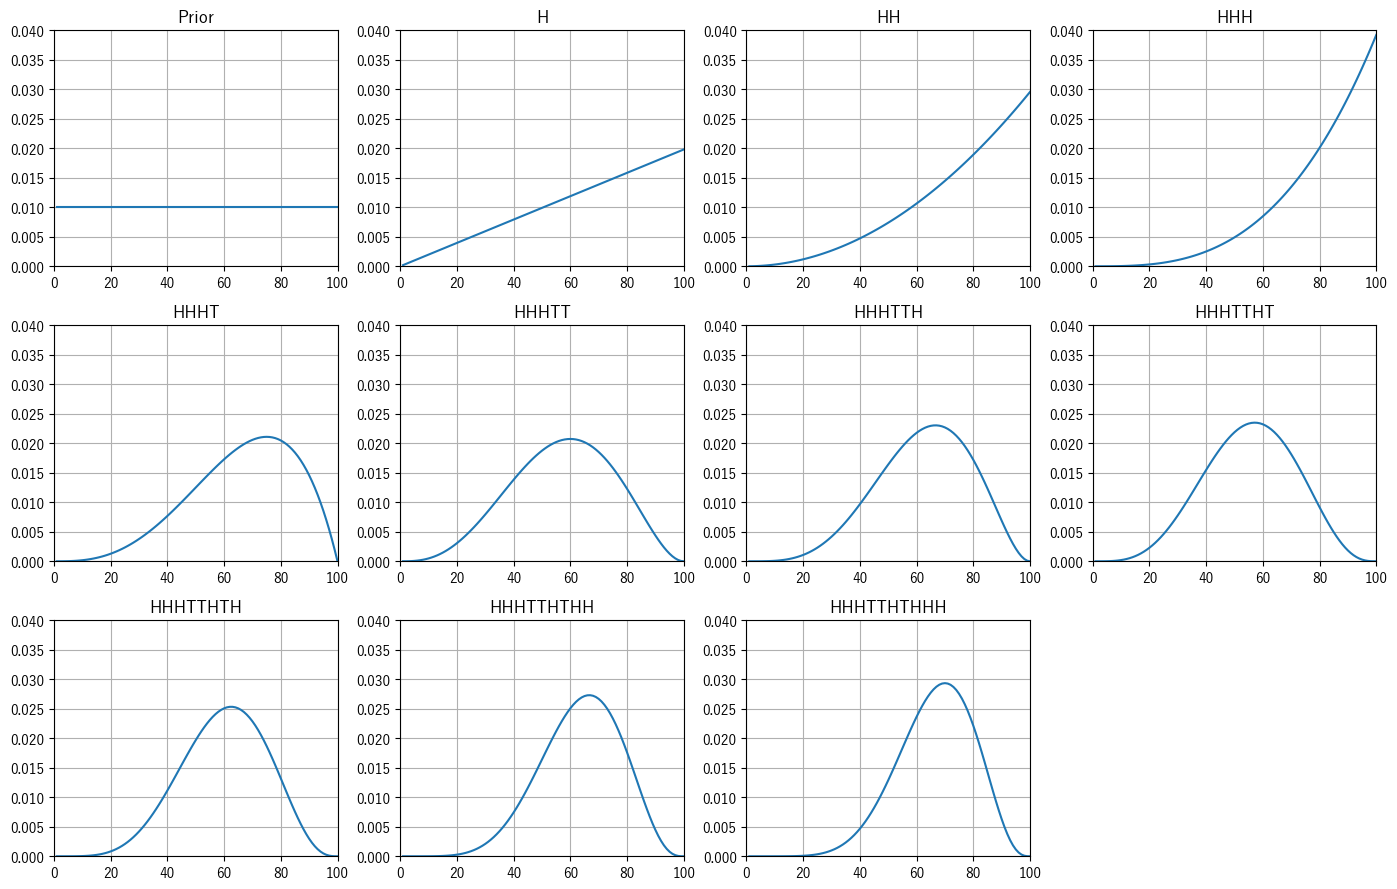

In [7]:
import matplotlib.pyplot as plt
from thinkbayes import Suite


# ------------------------------------
# コイン問題
# ------------------------------------
class Euro(Suite):

    def Likelihood(self, data, hypo):

        x = hypo / 100.0

        if data == 'H':
            return x
        else:
            return 1 - x


# ------------------------------------
# 仮説
# ------------------------------------
hypos = range(1, 101)
suite = Euro(hypos)

# ------------------------------------
# データ
# ------------------------------------
data = "HHTHTHTTHH"

data = "HHHHHHHHHH"

data = "TTTTTTTTTT"

data = "HTHTHTHTHT"

data = "HHHTTHTHHH"

# ------------------------------------
# 3行×4列（12枚）
# ------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(14, 9))

axes = axes.flat

# ==========
# Prior
# ==========
xs, ps = zip(*suite.Items())

axes[0].plot(xs, ps)
axes[0].set_title("Prior")
axes[0].set_xlim(0, 100)
axes[0].grid(True)

# ==========
# Updateごとに描画
# ==========
history = ""

for i, outcome in enumerate(data):

    history += outcome

    suite.Update(outcome)

    xs, ps = zip(*suite.Items())

    axes[i+1].plot(xs, ps)
    axes[i+1].set_title(history)
    axes[i+1].set_xlim(0, 100)
    axes[i+1].grid(True)

# 最後の1枚は空白
axes[-1].axis("off")

for ax in axes[:-1]:
    ax.set_ylim(0, 0.04)

plt.tight_layout()
plt.show()